In [1]:
#Data Cleaning

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
path = "D:/Projects/XFireAlert/data/tabular/Algerian_forest_fires_dataset.csv"
df = pd.read_csv(path)

df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [4]:
print(df.columns)

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  '],
      dtype='object')


In [5]:
df = df[df['day'] != 'day']
df = df[df['Classes  '] != 'Classes  ']


In [6]:
df.replace("?", np.nan, inplace=True)
df.dropna(inplace=True)


In [7]:
df['Classes  '] = df['Classes  '].astype(str).str.strip()



In [8]:
df['Classes  '] = df['Classes  '].map({'fire': 1, 'not fire': 0})


In [9]:
print(df.columns)

Index(['day', 'month', 'year', 'Temperature', ' RH', ' Ws', 'Rain ', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes  '],
      dtype='object')


In [10]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,0


In [11]:
df.columns = df.columns.str.strip().str.lower()

In [12]:
print(df.columns)

Index(['day', 'month', 'year', 'temperature', 'rh', 'ws', 'rain', 'ffmc',
       'dmc', 'dc', 'isi', 'bui', 'fwi', 'classes'],
      dtype='object')


In [13]:
df.columns = df.columns.str.strip().str.lower()

df.rename(columns={'classes':'fire_label'}, inplace=True)
df.head()


,day,month,year,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,fire_label
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,0


In [14]:
df['fire_label'].value_counts()


fire_label
1    137
0    106
Name: count, dtype: int64

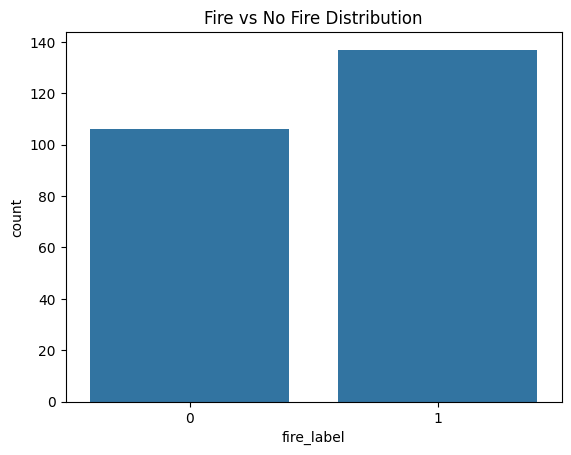

In [15]:
sns.countplot(x='fire_label', data=df)
plt.title("Fire vs No Fire Distribution")
plt.show()


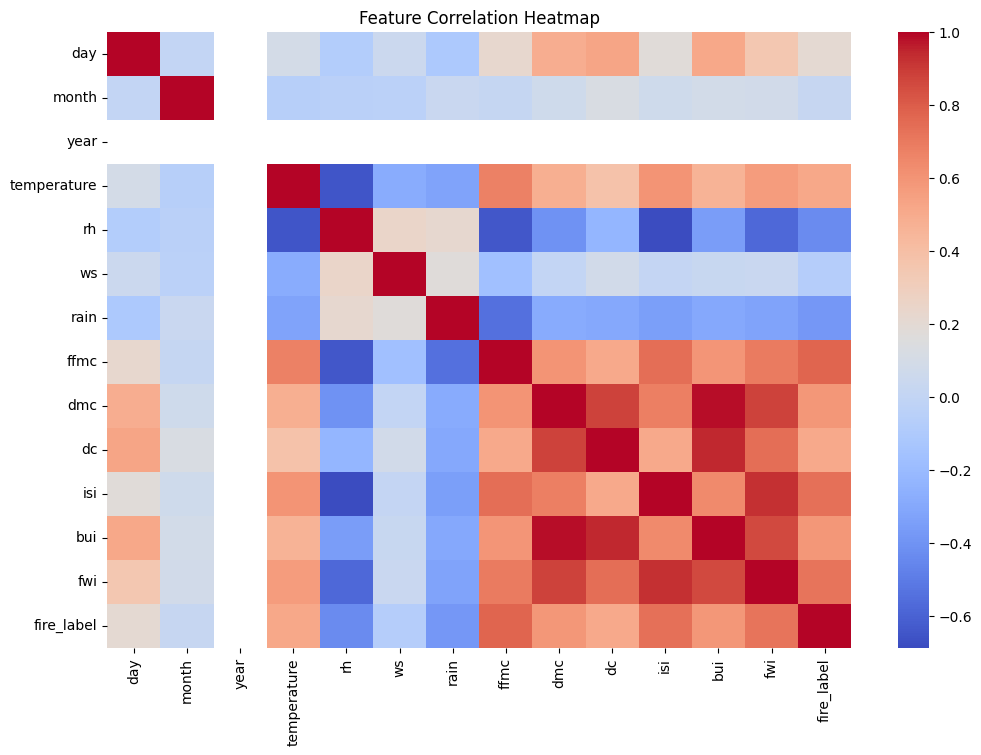

In [16]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


In [17]:
X = df.drop(columns=['fire_label','day','month','year'])
y = df['fire_label']

In [18]:
print(df['fire_label'].isna().sum())



0


In [19]:
df = df.dropna(subset=['fire_label']).reset_index(drop=True)


In [20]:
df[df['fire_label'].isna()].head(10)
df.head()

,day,month,year,temperature,rh,ws,rain,ffmc,dmc,dc,isi,bui,fwi,fire_label
0,1,6,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,0
4,5,6,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,0


In [21]:
df = df.dropna(subset=['fire_label']).reset_index(drop=True)


In [22]:
X = df.drop(columns=['fire_label'])
y = df['fire_label']


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [25]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

lr_acc = lr.score(X_test_scaled, y_test)
print("LR Accuracy:", lr_acc)



LR Accuracy: 0.9387755102040817


In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_acc = rf.score(X_test, y_test)
print("RF Accuracy:", rf_acc)


RF Accuracy: 1.0


In [27]:
from sklearn.svm import SVC

svm = SVC(probability=True)
svm.fit(X_train_scaled, y_train)

svm_acc = svm.score(X_test_scaled, y_test)
print("SVM Accuracy:", svm_acc)


SVM Accuracy: 0.8979591836734694


In [28]:
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

In [29]:
import pandas as pd

X = pd.DataFrame(X)
y = pd.Series(y)

data = pd.concat([X, y], axis=1)
data = data.dropna().reset_index(drop=True)

X = data.drop(columns=['fire_label'])
y = data['fire_label']


In [30]:
print(X.dtypes)


day              int64
month            int64
year             int64
temperature      int64
rh               int64
ws               int64
rain           float64
ffmc           float64
dmc            float64
dc             float64
isi            float64
bui            float64
fwi            float64
dtype: object


In [31]:
# Combines back
data = pd.concat([X, y], axis=1)

# Converts ALL feature columns to numeric
for col in data.columns:
    if col != 'fire_label':
        data[col] = pd.to_numeric(data[col], errors='coerce')

# Removes the duplicate header rows & bad rows
data = data.dropna().reset_index(drop=True)

# Recreates X and y
X = data.drop(columns=['fire_label'])
y = data['fire_label']



In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [33]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

print("XGB Accuracy:", xgb.score(X_test, y_test))


XGB Accuracy: 0.9591836734693877


In [34]:
import joblib

joblib.dump(xgb, "../models/risk_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")


['../models/scaler.pkl']